In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam


In [ ]:
ROOT_DIR = "chb"

CLASS_MAP = {
    "interictal": [
        "Non-Seizure/n2"
    ],
    "ictal": ["Seizure/ictal"],
    "postictal": ["Seizure/postictal"]
}

LABEL_MAP = {
    "interictal": 0,
    "ictal": 1,
    "postictal": 2
}


In [ ]:
import numpy as np
import os

def load_eeg_data(root_dir, num_channels=23, fs=256):

    WINDOW_SECONDS = 5
    STRIDE_SECONDS = 1
    
    window_samples = int(fs * WINDOW_SECONDS)  
    stride_samples = int(fs * STRIDE_SECONDS)  
    
    X, y = [], []

    label_from_dir = {
        "non-seizure": LABEL_MAP["interictal"],
        "ictal": LABEL_MAP["ictal"],
        "postictal": LABEL_MAP["postictal"],
    }

    print(f"Scanning {root_dir}...")
    
    for root, _, files in os.walk(root_dir):
        root_lower = root.lower()

        label = None
        for key, value in label_from_dir.items():
            if key in root_lower:
                label = value
                break

        if label is None:
            continue

        for file in files:
            if not file.endswith(".csv"):
                continue

            file_path = os.path.join(root, file)

            try:
                
                eeg = np.loadtxt(file_path, delimiter=",")

        
                if eeg.ndim == 1: eeg = eeg.reshape(-1, 1)
             
                if eeg.shape[0] < eeg.shape[1]:
                    eeg = eeg.T

        
                if eeg.shape[1] > num_channels:
                    eeg = eeg[:, :num_channels]
                elif eeg.shape[1] < num_channels:
                    pad_width = num_channels - eeg.shape[1]
                    eeg = np.pad(eeg, ((0, 0), (0, pad_width)), mode="constant")

            
                num_samples = eeg.shape[0]
                
              
                if num_samples < window_samples:
                    continue

                start = 0
                while (start + window_samples) <= num_samples:
                    end = start + window_samples
                    
              
                    window = eeg[start:end, :] 
                    
                    X.append(window)
                    y.append(label)
                    
                    
                    start += stride_samples

            except Exception as e:
                print(f"Error loading {file_path}: {e}")
                continue

    if not X:
        raise ValueError("No valid data files found!")

    print(f"Generated {len(X)} windows.")
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

In [ ]:
X, y = load_eeg_data(ROOT_DIR, num_channels=23)

print("X shape (1D CNN input):", X.shape)
print("y shape:", y.shape)


In [ ]:
print("Final X shape:", X.shape)
print("Input shape for model (1D CNN):", X.shape[1:])

In [ ]:
def build(input_shape):
    model = Sequential([

        Conv1D(
            filters=8,
            kernel_size=6,
            strides=1,
            activation="relu",
            input_shape=input_shape
        ),

        MaxPooling1D(pool_size=2, strides=2),

        Conv1D(
            filters=8,
            kernel_size=5,
            strides=1,
            activation="relu"
        ),

        MaxPooling1D(pool_size=2, strides=2),

        Conv1D(
            filters=16,
            kernel_size=4,
            strides=1,
            activation="relu"
        ),

        MaxPooling1D(pool_size=2, strides=2),

        Conv1D(
            filters=16,
            kernel_size=4,
            strides=1,
            activation="relu"
        ),

        MaxPooling1D(pool_size=2, strides=2),

        Conv1D(
            filters=32,
            kernel_size=4,
            strides=1,
            activation="relu"
        ),

        MaxPooling1D(pool_size=2, strides=2),

        GlobalAveragePooling1D(),

        Dense(50, activation="relu"),

        Dense(20, activation="relu"),

        Dense(3, activation="softmax")
    ])

    return model

In [ ]:
X_train, X_Temp, y_train, y_Temp = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  
)

X_test,X_val,y_test,y_val = train_test_split(
    X_Temp,y_Temp,
    test_size=0.5,
    random_state=42,
    stratify=y_Temp
)


print(f"Training shapes: {X_train.shape}, {y_train.shape}")
print(f"Validation shapes: {X_val.shape}, {y_val.shape}")

In [ ]:

model = build(input_shape=X.shape[1:])
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nStarting training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=32,
    verbose=1
)


y_val_pred_probs = model.predict(X_val, verbose=0)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)

print("-" * 30)
print(f"Final Validation Accuracy: {val_accuracy:.4f}")
print(f"Final Validation Loss: {val_loss:.4f}")


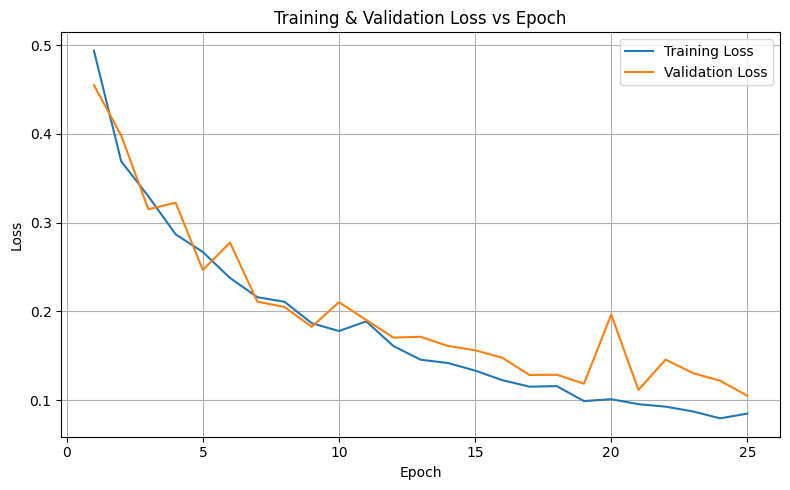

In [17]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
results = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss:     {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

Test Loss:     0.1123
Test Accuracy: 0.9657


In [16]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


tn, fp, fn, tp = confusion_matrix(y_test, y_pred_classes).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Specificity : {specificity:.4f}")
print(f"Sensitivity : {sensitivity:.4f}")

151/151 [==============================] - 1s 5ms/step
Specificity : 0.9547
Sensitivity : 0.9713
